In [913]:
'''
Russell Larkin
DATA430 - Project Four
Professor Yamil Guevara
'''

'\nRussell Larkin\nDATA430 - Project Four\nProfessor Yamil Guevara\n'

In [914]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global constants
RANDOM_STATE = 4

In [915]:
#Load the dataset and display the first few rows
df = pd.read_csv('wine-quality-white-and-red 2.csv')
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [916]:
value_counts = df['quality'].value_counts()
display(value_counts)

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [917]:
# Drop the 'quality' column as it is not needed for clustering and 'type' as it is categorical
df = df.drop(columns=['type'])
print(df.isna().sum())  # Check for missing values

df.info()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   su

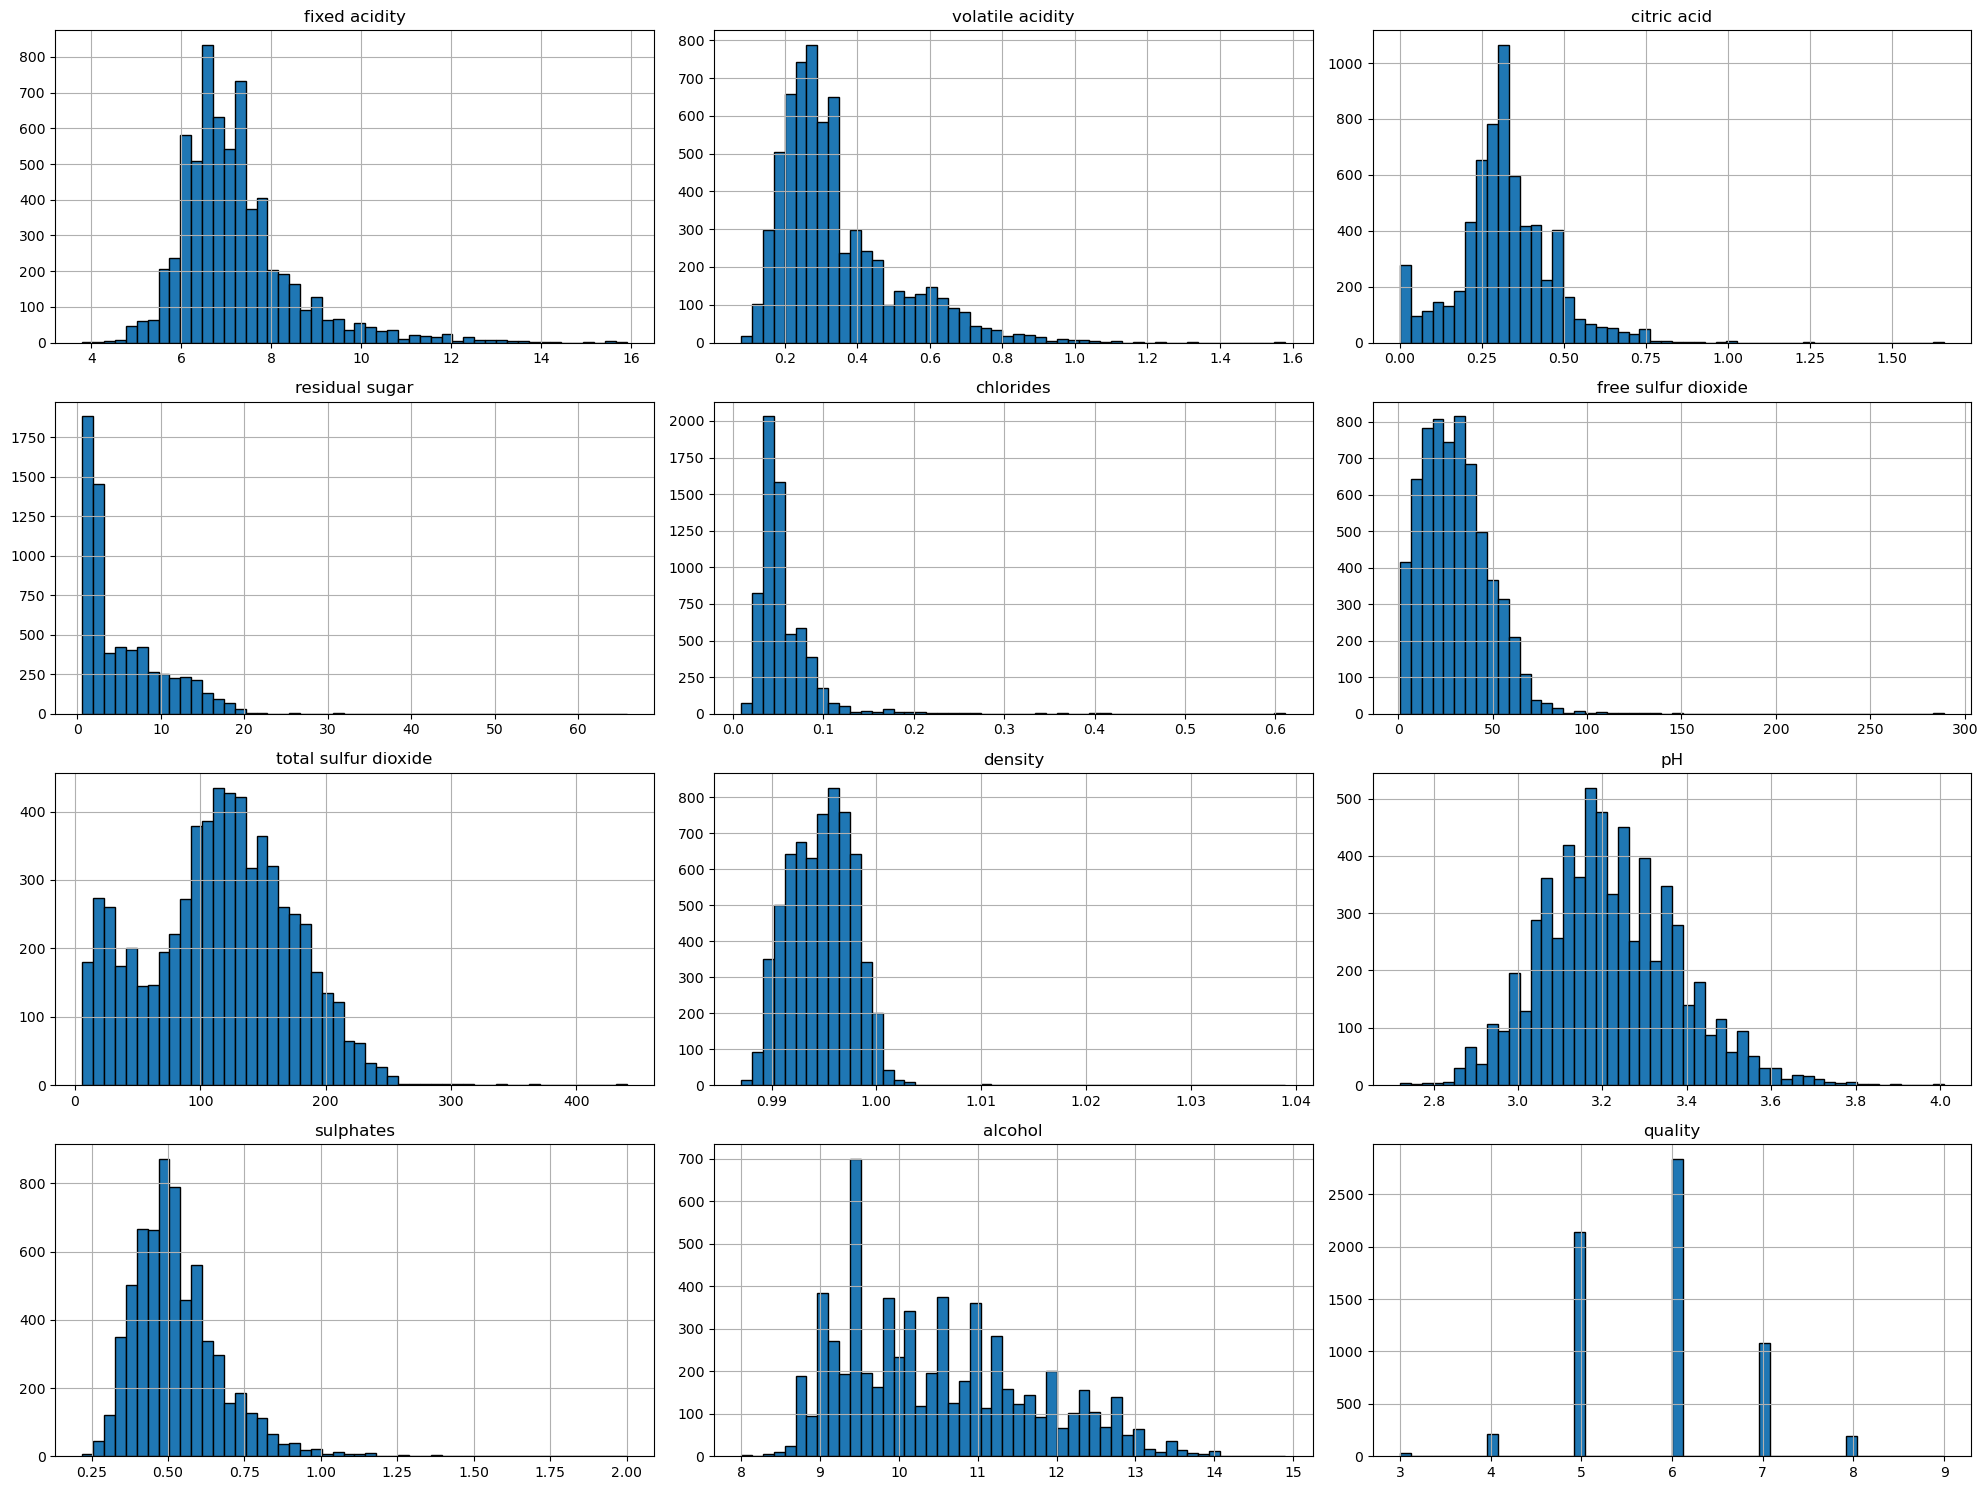

In [918]:
# Histogram to visualize the dataset
df.hist(figsize=(20, 15), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()


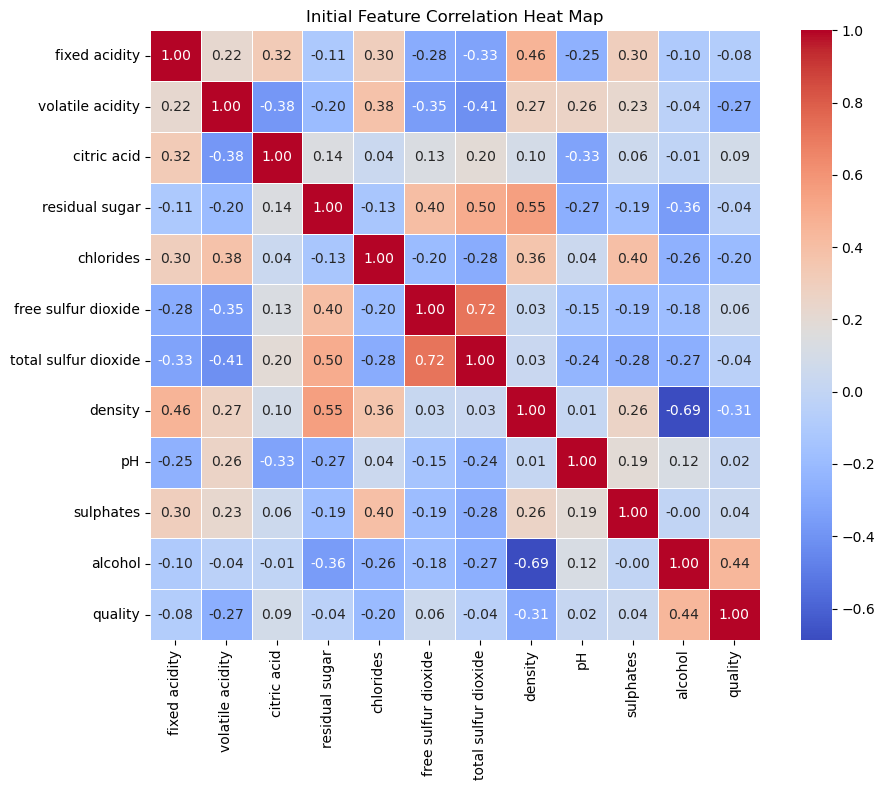

In [919]:
# Feature correlation heat-map to ensure multicollinearity < 0.8
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=.5)
plt.title('Initial Feature Correlation Heat Map')
plt.tight_layout()
plt.show()

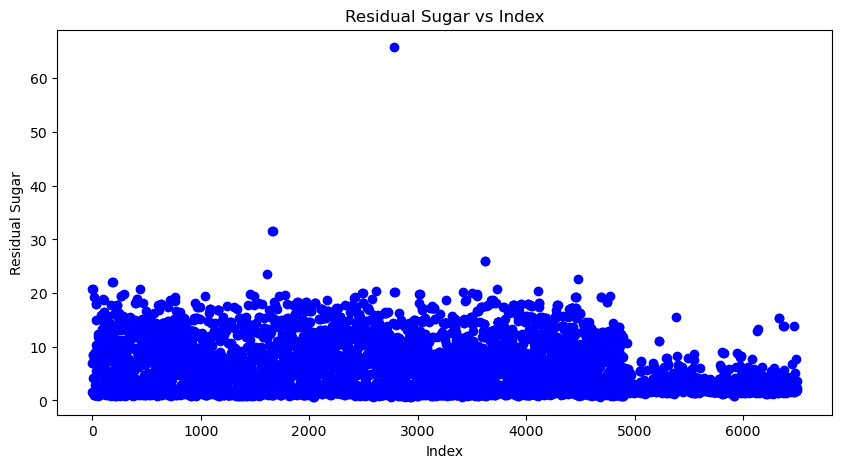

In [920]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['residual sugar'], color='blue')
plt.title('Residual Sugar vs Index')
plt.xlabel('Index')
plt.ylabel('Residual Sugar')
plt.show()


In [921]:
# Remove outliers based on the scatter plot
df = df[df['residual sugar'] <= 30.00]

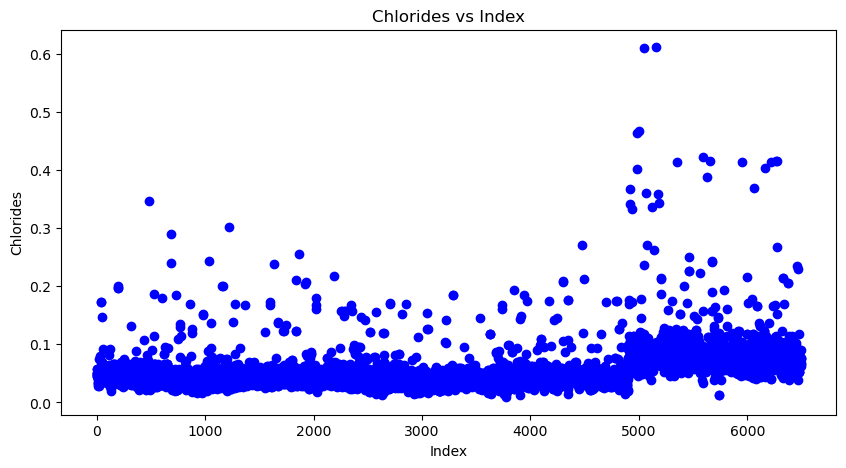

In [922]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['chlorides'], color='blue')
plt.title('Chlorides vs Index')
plt.xlabel('Index')
plt.ylabel('Chlorides')
plt.show()

In [923]:
# Remove outliers based on the scatter plot
df = df[df['chlorides'] <= .45]

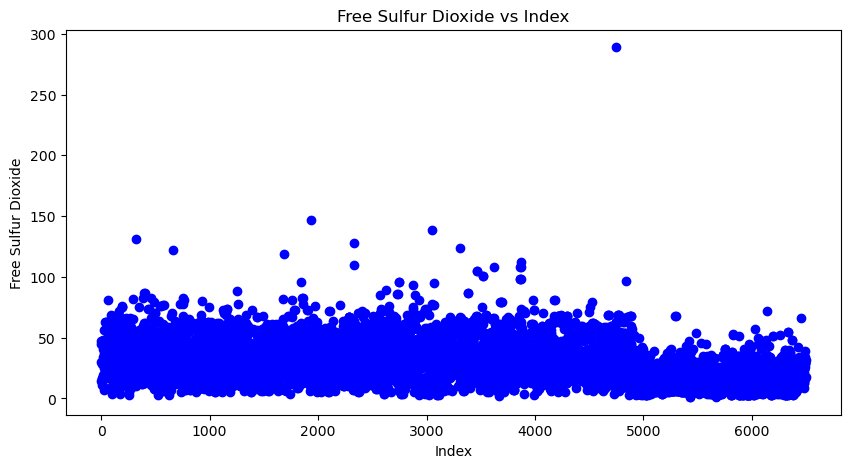

In [924]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['free sulfur dioxide'], color='blue')
plt.title('Free Sulfur Dioxide vs Index')
plt.xlabel('Index')
plt.ylabel('Free Sulfur Dioxide')
plt.show()

In [925]:
# Remove outliers based on the scatter plot
df = df[df['free sulfur dioxide'] <= 150]

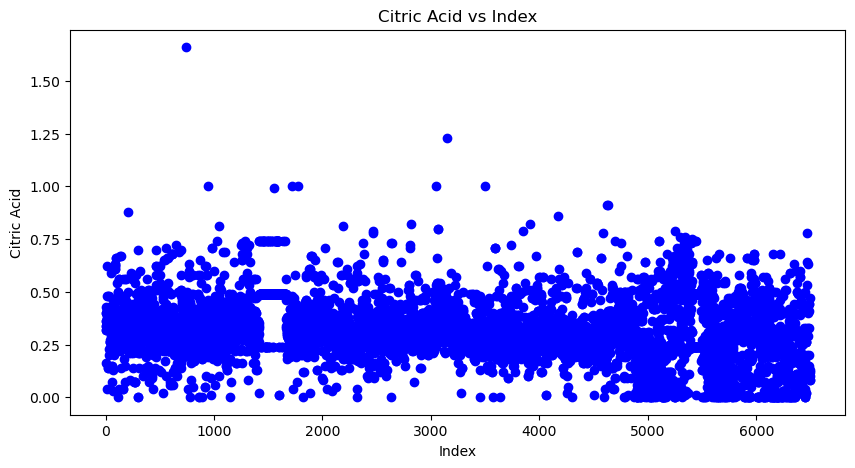

In [926]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['citric acid'], color='blue')
plt.title('Citric Acid vs Index')
plt.xlabel('Index')
plt.ylabel('Citric Acid')
plt.show()

In [927]:
# Remove outliers based on the scatter plot
df = df[df['citric acid'] <= 1.20]

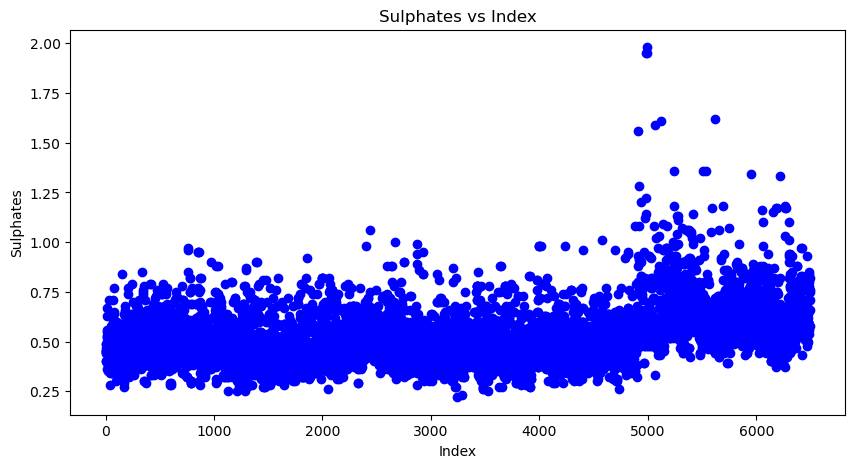

In [928]:
plt.figure(figsize=(10, 5))
plt.scatter(df.index, df['sulphates'], color='blue')
plt.title('Sulphates vs Index')
plt.xlabel('Index')
plt.ylabel('Sulphates')
plt.show()

In [929]:
# Remove outliers based on the scatter plot
df = df[df['sulphates'] <= 1.75]

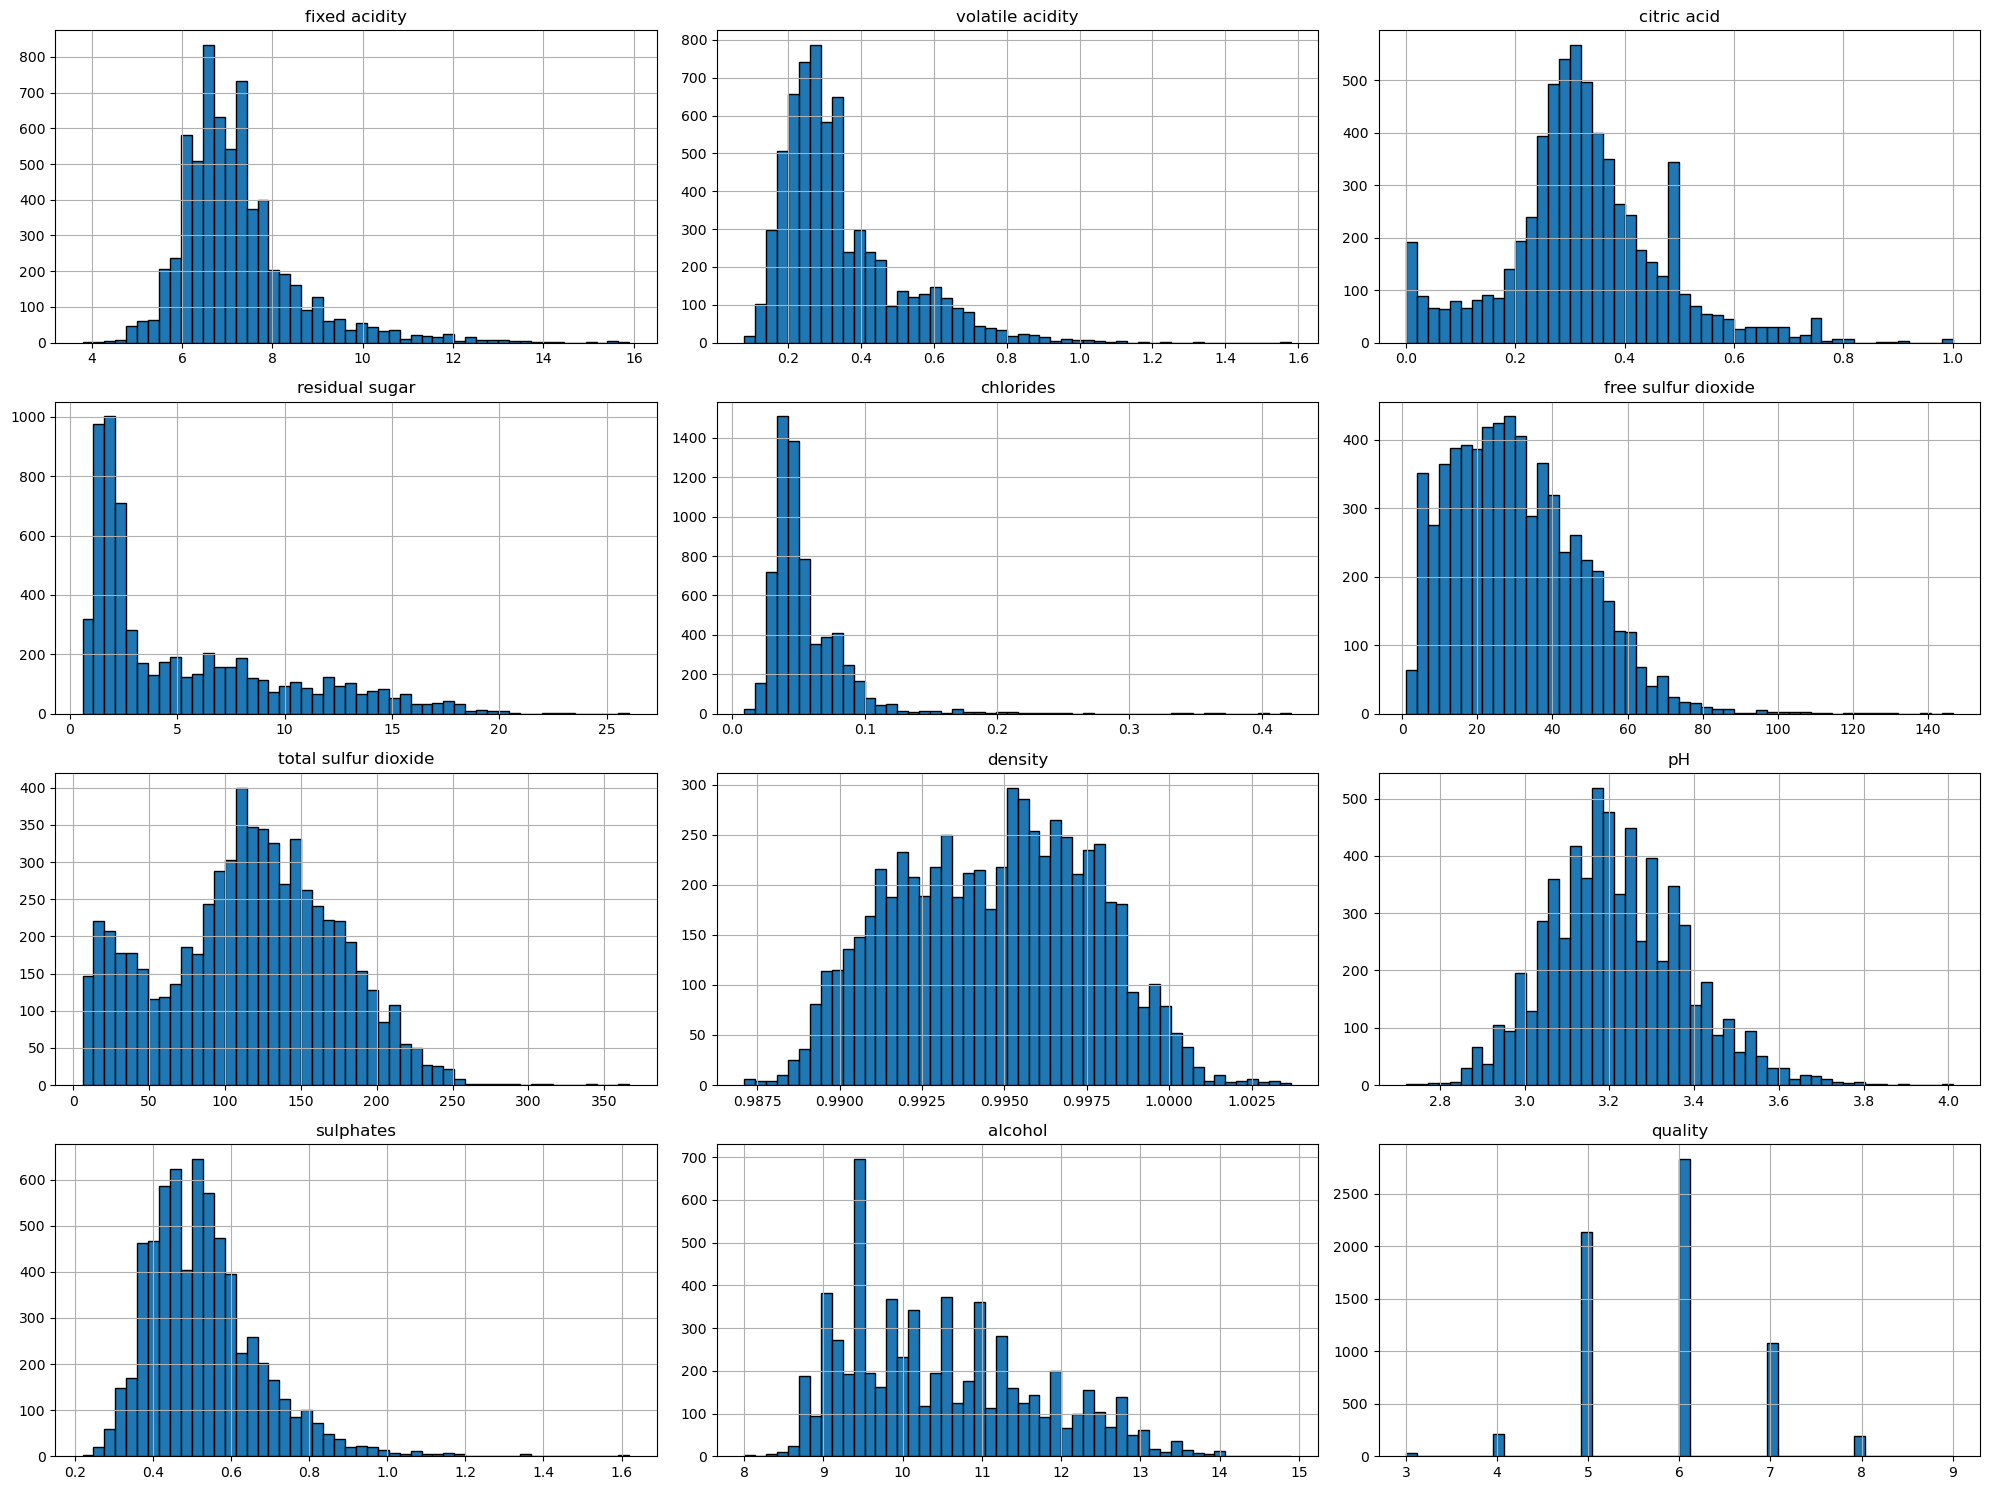

In [930]:
# Final histogram to visualize the cleaned dataset
df.hist(figsize=(20, 15), bins=50, edgecolor='black')
plt.tight_layout()
plt.show()

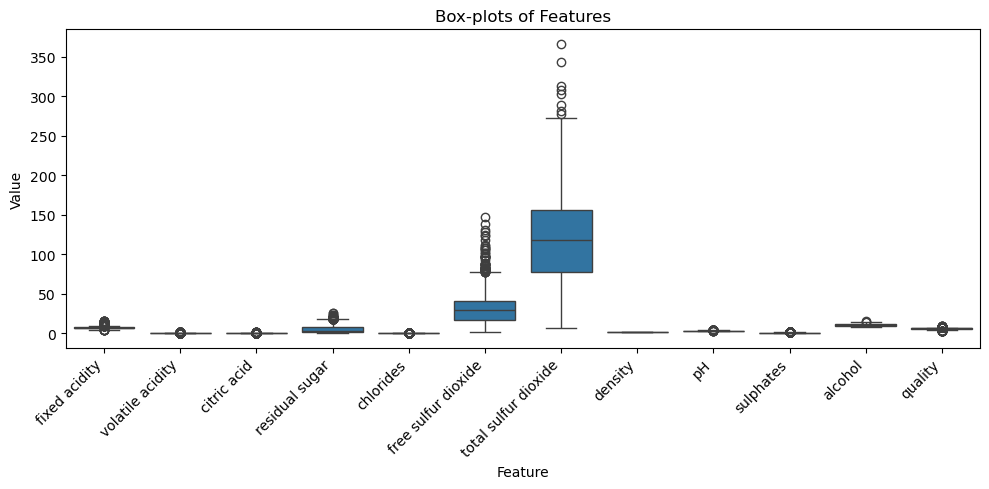

In [931]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.melt(var_name='Feature', value_name='Value'),
            x='Feature', y='Value')
plt.title('Box-plots of Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [932]:
# Keep a copy of the original DataFrame and remove 'quality' column for clustering
raw_df = df.copy()
df = df.drop(columns=['quality'])

In [933]:
# Scale the features using StandardScaler
# This is necessary for K-Means clustering to ensure all features contribute equally to the distance calculations
import numpy as np
from sklearn.preprocessing import StandardScaler

X = df.values
X = np.nan_to_num(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
display(X_scaled)

array([[-0.16493009, -0.42232697,  0.29272867, ..., -1.36190528,
        -0.55734666, -1.41945396],
       [-0.70470345, -0.23999398,  0.15335556, ...,  0.50584395,
        -0.2788505 , -0.83236471],
       [ 0.6832852 , -0.3615493 ,  0.57147489, ...,  0.25681072,
        -0.6269707 , -0.32914535],
       ...,
       [-0.70470345,  1.03633698, -1.3100621 , ...,  1.25294364,
         1.5313745 ,  0.42568369],
       [-1.01314538,  1.85683545, -1.37974866, ...,  2.18681825,
         1.25287835, -0.24527546],
       [-0.9360349 , -0.17921631,  1.05928078, ...,  1.06616872,
         0.90475816,  0.42568369]])

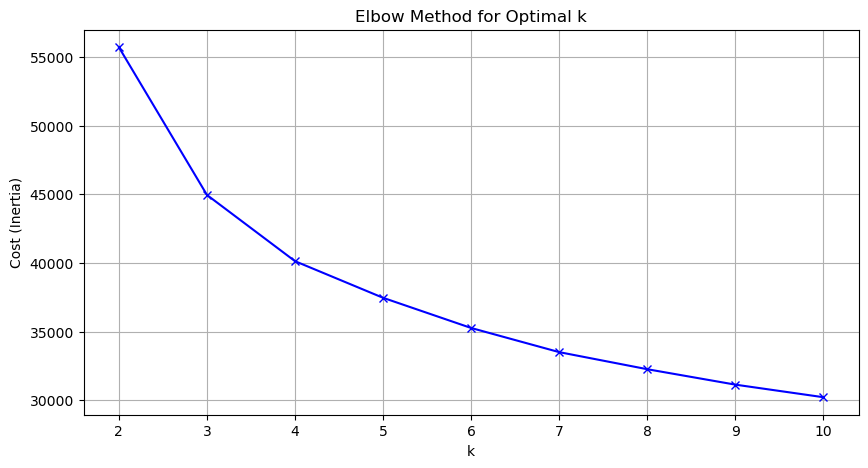

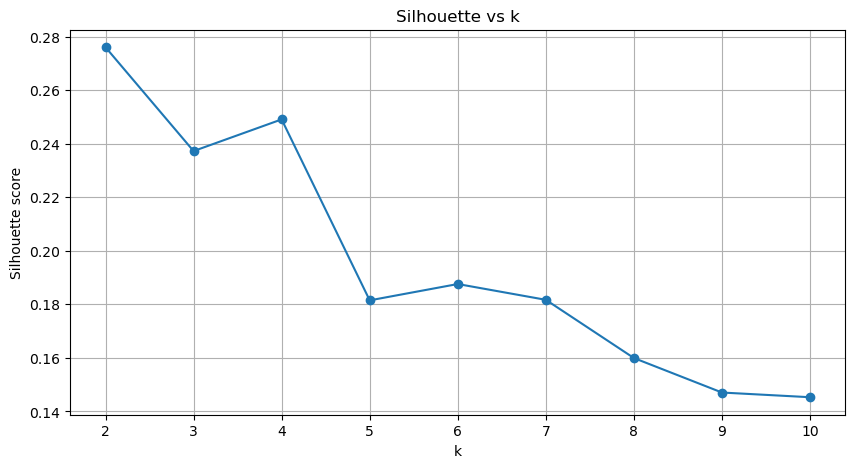

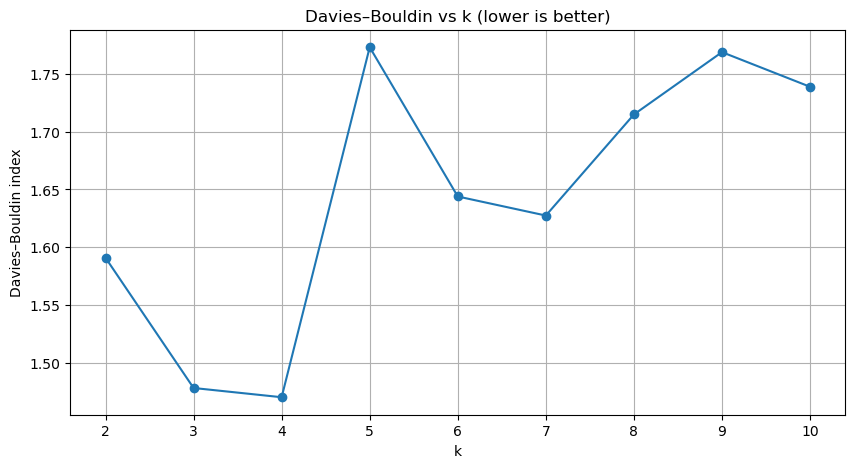

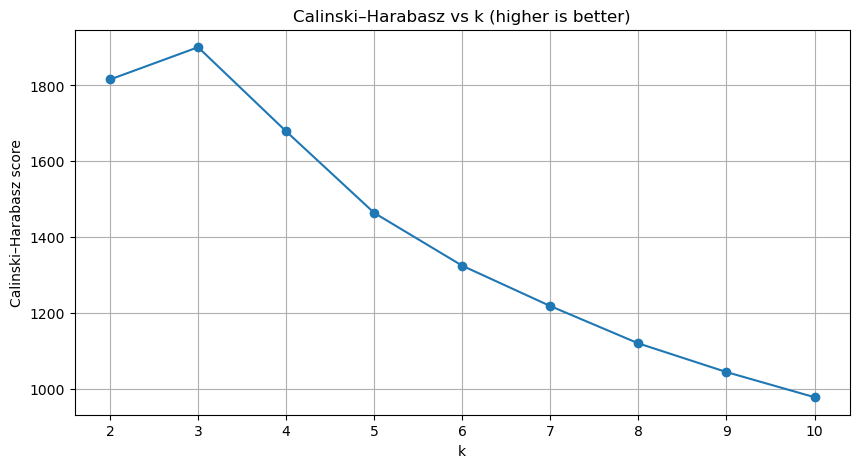

In [934]:
# K-Means Clustering with Elbow Method and Evaluation Metrics

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K = range(2, 11)
sil_scores, db_scores, ch_scores, inertias = [], [], [], []

for k in K:
    km = KMeans(n_clusters=k, n_init=12, init='k-means++',
                random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)

    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    inertias.append(km.inertia_)


# Elbow (Cost (inertia))
plt.figure(figsize=(10, 5))
plt.plot(K, inertias, 'bx-')
plt.xticks(K); plt.grid(True)
plt.xlabel('k'); plt.ylabel('Cost (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

# Silhouette
plt.figure(figsize=(10, 5))
plt.plot(K, sil_scores, marker='o')
plt.xticks(K); plt.grid(True)
plt.xlabel('k'); plt.ylabel('Silhouette score')
plt.title('Silhouette vs k')
plt.show()

# Davies–Bouldin
plt.figure(figsize=(10, 5))
plt.plot(K, db_scores, marker='o')
plt.xticks(K); plt.grid(True)
plt.xlabel('k'); plt.ylabel('Davies–Bouldin index')
plt.title('Davies–Bouldin vs k (lower is better)')
plt.show()

# Calinski–Harabasz
plt.figure(figsize=(10, 5))
plt.plot(K, ch_scores, marker='o')
plt.xticks(K); plt.grid(True)
plt.xlabel('k'); plt.ylabel('Calinski–Harabasz score')
plt.title('Calinski–Harabasz vs k (higher is better)')
plt.show()


In [935]:
# Final clustering with the chosen k

best_k = 4
k_means = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=12,
    random_state=RANDOM_STATE
)
labels = k_means.fit_predict(X_scaled)

print(f"Chosen k = {best_k}")
print(f"Silhouette:        {silhouette_score(X_scaled, labels):.3f}")
print(f"Davies–Bouldin:    {davies_bouldin_score(X_scaled, labels):.3f}")
print(f"Calinski–Harabasz: {calinski_harabasz_score(X_scaled, labels):.1f}")


Chosen k = 4
Silhouette:        0.249
Davies–Bouldin:    1.470
Calinski–Harabasz: 1679.0


In [936]:
# Add cluster labels and quality to the DataFrame

df['cluster'] = labels
df['quality'] = raw_df['quality']
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,cluster,quality
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,0,6
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,2,6
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,2,6
3,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0,6
4,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1,5
6493,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1,6
6494,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,1,6
6495,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1,5


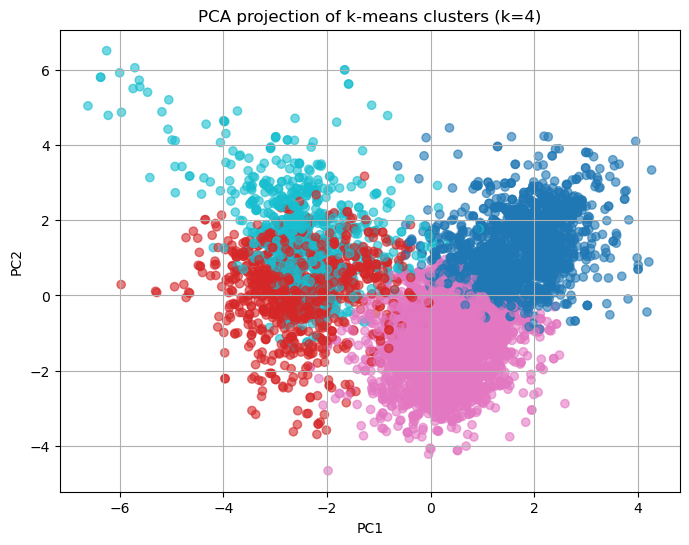

In [937]:
# PCA scatter coloured by cluster
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap='tab10', alpha=0.6)
plt.title('PCA projection of k-means clusters (k=4)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.grid(True)
plt.show()


In [945]:
# columns used for clustering (everything except cluster + quality)
feature_cols = [c for c in df.columns if c not in ('cluster', 'quality')]

# 👉 add these two lines so 'centroids' is always defined
centroids_scaled = k_means.cluster_centers_
centroids        = scaler.inverse_transform(centroids_scaled)

centroid_df = (
    pd.DataFrame(centroids, columns=feature_cols)      # 11 cols ↔ 11 features
      .assign(cluster=range(k_means.n_clusters))       # 0-based labels
      .set_index('cluster')
      .round(2)
)

# quality stats & merge stay the same
quality_stats = (
    df.groupby('cluster')['quality']
      .agg(['count', 'mean', 'median', 'std'])
      .round(2)
      .rename(columns={'mean': 'avg_quality', 'std': 'std_dev'})
)

centroid_df['avg_quality'] = quality_stats['avg_quality']
display(quality_stats)
display(centroid_df)


,count,avg_quality,median,std_dev
cluster,,,,
0,1868,5.63,6.0,0.76
1,1004,5.40,5.0,0.75
2,2918,6.08,6.0,0.89
3,694,5.82,6.0,0.87


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,avg_quality
cluster,,,,,,,,,,,,
0,6.96,0.28,0.36,11.18,0.05,45.62,169.85,1.00,3.16,0.49,9.54,5.63
1,7.25,0.61,0.14,2.50,0.08,16.84,53.59,1.00,3.37,0.59,10.22,5.40
2,6.78,0.27,0.32,3.38,0.04,29.22,118.53,0.99,3.21,0.49,11.18,6.08
3,9.68,0.41,0.46,2.80,0.10,14.93,47.59,1.00,3.21,0.72,10.54,5.82


In [946]:
# Legend for the clusters
from matplotlib.lines import Line2D

cluster_ids = sorted(df['cluster'].unique())
colors = plt.cm.tab10(cluster_ids)
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=colors[i], markersize=8,
                  label=f'Cluster {cid}')
           for i, cid in enumerate(cluster_ids)]

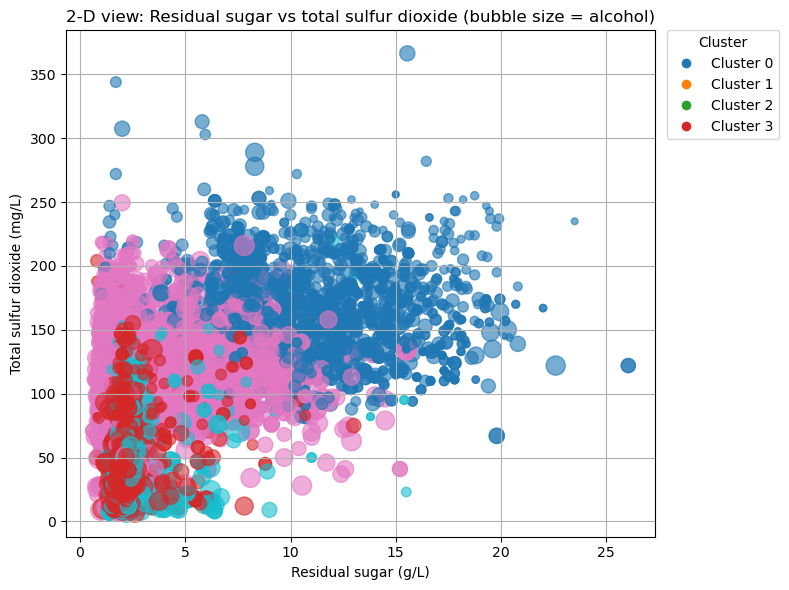

In [941]:
# Scatter plot of residual sugar vs total sulfur dioxide, colored by cluster
plt.figure(figsize=(8, 6))

sizes = (df['alcohol'] - df['alcohol'].min()) * 40
scatter = plt.scatter(df['residual sugar'], df['total sulfur dioxide'],
                      c=df['cluster'], cmap='tab10', s=sizes, alpha=0.6)

plt.xlabel('Residual sugar (g/L)')
plt.ylabel('Total sulfur dioxide (mg/L)')
plt.title('2-D view: Residual sugar vs total sulfur dioxide (bubble size = alcohol)')
plt.grid(True)

plt.legend(handles=handles, title='Cluster', bbox_to_anchor=(1.02, 1),
           loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


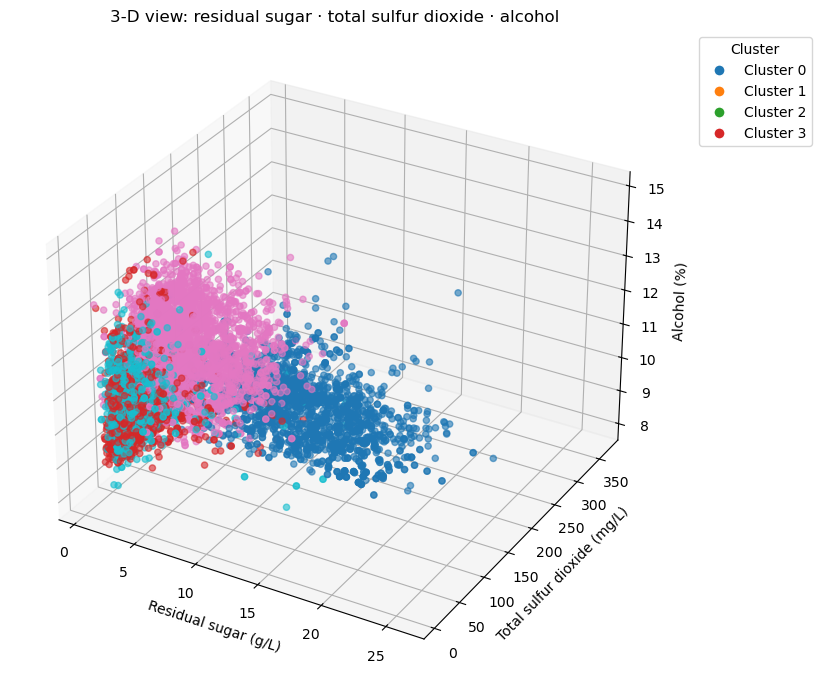

In [942]:
# 3D scatter plot of residual sugar, total sulfur dioxide, and alcohol, colored by cluster
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')

scatter3d = ax.scatter(df['residual sugar'], df['total sulfur dioxide'],
                       df['alcohol'], c=df['cluster'], cmap='tab10', alpha=0.6)

ax.set_xlabel('Residual sugar (g/L)')
ax.set_ylabel('Total sulfur dioxide (mg/L)')
ax.set_zlabel('Alcohol (%)')
ax.set_title('3-D view: residual sugar · total sulfur dioxide · alcohol')

ax.legend(handles=handles, title='Cluster', bbox_to_anchor=(1.05, 1),
          loc='upper left')
plt.tight_layout()
plt.show()
